### Self RAG

In Self-RAG, the model doesn’t just retrieve info blindly—it also:

Decides when it needs retrieval
Evaluates the quality of retrieved information
Reflects on its own answer and improves it

In [146]:
import os
from dotenv import load_dotenv

load_dotenv()

True

In [147]:
GOOGLE_API_KEY=os.getenv("GOOGLE_API_KEY")
LANGCHAIN_API_KEY=os.getenv("LANGCHAIN_API_KEY")

os.environ["GOOGLE_API_KEY"] = GOOGLE_API_KEY
os.environ["LANGCHAIN_API_KEY"] = LANGCHAIN_API_KEY
os.environ["LANGCHAIN_TRACING_V2"] = "true"
os.environ["LANGCHAIN_ENDPOINT"] = "https://api.smith.langchain.com"

In [148]:
import warnings
# Suppress all warnings
warnings.filterwarnings("ignore")

In [149]:
# loading the embeddings model
from langchain_huggingface import HuggingFaceEmbeddings
from langchain_groq import ChatGroq

embeddings = HuggingFaceEmbeddings(
    model_name="sentence-transformers/all-MiniLM-L6-v2"
)

llm=ChatGroq(model="llama-3.1-8b-instant")

Loading weights: 100%|██████████| 103/103 [00:00<00:00, 18073.60it/s]


In [150]:
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_community.document_loaders import WebBaseLoader
from langchain_community.vectorstores import Chroma
urls = [
    "https://lilianweng.github.io/posts/2023-06-23-agent/",
    "https://lilianweng.github.io/posts/2023-03-15-prompt-engineering/",
]

docs = [WebBaseLoader(url).load() for url in urls]
docs_list = [item for sublist in docs for item in sublist]

text_splitter = RecursiveCharacterTextSplitter.from_tiktoken_encoder(
    chunk_size=100, chunk_overlap=50
)
doc_splits = text_splitter.split_documents(docs_list)

# Add to vectorDB
vectorstore = Chroma.from_documents(
    documents=doc_splits,
    collection_name="rag-chroma",
    embedding=embeddings,
)

retriever = vectorstore.as_retriever()

In [151]:
from langchain_core.tools.retriever import create_retriever_tool

retriever_tool=create_retriever_tool(retriever,"retrieve_blog_posts",
    "Search and return information about Lilian Weng blog posts on LLM agents, prompt engineering, and adversarial attacks on LLMs.",
)

tools=[retriever_tool]


In [ ]:
## retreiver grader
from langchain_core.prompts import ChatPromptTemplate
from pydantic import BaseModel, Field


In [ ]:
class GradeDocuments(BaseModel):
    """Binary score for relevance check on retrieved documents."""

    binary_score: str = Field(
        description="Documents are relevant to the question, 'yes' or 'no'"
    )

In [ ]:
structured_llm_grader=llm.with_structured_output(GradeDocuments)

In [ ]:
# Prompt
system = """
You are a grader assessing whether an answer addresses / resolves a question.

Return:
- 'yes' if the answer sufficiently answers the question
- 'no' otherwise
"""

grade_prompt=ChatPromptTemplate.from_messages(
    [
        ("system",system),
        ("human","Retrieved document: \n\n {document} \n\n User question: {question}")
    ]
)

In [ ]:
my_retrieval_grader=grade_prompt | structured_llm_grader

In [ ]:
question="What is an ai agent"
docs=retriever.invoke(question)

In [ ]:
docs

[Document(metadata={'language': 'en', 'description': 'Building agents with LLM (large language model) as its core controller is a cool concept. Several proof-of-concepts demos, such as AutoGPT, GPT-Engineer and BabyAGI, serve as inspiring examples. The potentiality of LLM extends beyond generating well-written copies, stories, essays and programs; it can be framed as a powerful general problem solver.\nAgent System Overview\nIn a LLM-powered autonomous agent system, LLM functions as the agent’s brain, complemented by several key components:\n\nPlanning\n\nSubgoal and decomposition: The agent breaks down large tasks into smaller, manageable subgoals, enabling efficient handling of complex tasks.\nReflection and refinement: The agent can do self-criticism and self-reflection over past actions, learn from mistakes and refine them for future steps, thereby improving the quality of final results.\n\n\nMemory\n\nShort-term memory: I would consider all the in-context learning (See Prompt Engi

In [ ]:
doc_txt=docs[2].page_content

In [ ]:
doc_txt

'Tool use\n\nThe agent learns to call external APIs for extra information that is missing from the model weights (often hard to change after pre-training), including current information, code execution capability, access to proprietary information sources and more.\n\n\n\n\n\nOverview of a LLM-powered autonomous agent system.'

In [ ]:
print(my_retrieval_grader.invoke({"document":doc_txt,"question":question}))

BadRequestError: Error code: 400 - {'error': {'message': "Failed to call a function. Please adjust your prompt. See 'failed_generation' for more details.", 'type': 'invalid_request_error', 'code': 'tool_use_failed', 'failed_generation': "<function=GradeDocuments>binary_score='yes'</function>"}}

In [ ]:
question="who is sunny svaita?"

In [ ]:
print(my_retrieval_grader.invoke({"document":doc_txt,"question": question}))

binary_score='no'


In [ ]:
## Data Generation

rag_prompt = ChatPromptTemplate.from_messages([
    (
        "system",
        """
You are a helpful AI assistant for question-answering tasks.

Use ONLY the provided context to answer the user's question.

Instructions:
- Read the context carefully before answering.
- If the answer is clearly present in the context, provide a concise and accurate answer.
- If the context contains partial information, answer using only that information.
- If the answer cannot be found in the context, respond with:
  "I don't know based on the provided context."
- Do not make up information.
- Do not use external knowledge.
- Structure the answer clearly and naturally.

Retrieved Context:
{context}
"""
    ),
    (
        "human",
        """
Question:
{question}
"""
    )
])

In [ ]:
rag_chain=rag_prompt | llm

In [ ]:
question="what is a AI agent?"


In [ ]:
generation=rag_chain.invoke({"context":docs,"question":question})

In [ ]:
generation

AIMessage(content="Based on the provided context, an AI agent is described as a system that includes a Large Language Model (LLM) as its core controller, complemented by several key components. The main components mentioned are:\n\n1. Planning: Breaking down large tasks into smaller, manageable subgoals, enabling efficient handling of complex tasks.\n2. Memory: Utilizing both short-term and long-term memory to retain and recall information.\n3. Tool use: The ability to call external APIs for extra information that is missing from the model weights.\n\nThe AI agent is referred to as an autonomous agent system, where the LLM functions as the agent's brain. This suggests that an AI agent is a type of artificial intelligence system designed to perform tasks, make decisions, and learn from its environment, with the LLM serving as its primary controller.", additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 166, 'prompt_tokens': 1803, 'total_tokens': 1969, 'completi

In [ ]:
## Hallucination Grader

class GradeHallucinations(BaseModel):
    """Binary score for hallucination present in generation answer."""

    binary_score: str = Field(
        description="Answer is grounded in the facts, 'yes' or 'no'"
    )

In [ ]:
structured_llm_grader=llm.with_structured_output(GradeHallucinations)

In [ ]:
# Prompt
system = """
You are a grader assessing whether an answer addresses / resolves a question.

Return:
- 'yes' if the answer sufficiently answers the question
- 'no' otherwise
"""
hallucination_prompt = ChatPromptTemplate.from_messages(
    [
        ("system", system),
        ("human", "Set of facts: \n\n {documents} \n\n LLM generation: {generation}"),
    ]
)

In [ ]:
hallucinations_grader=hallucination_prompt | structured_llm_grader

In [ ]:
print(hallucinations_grader.invoke({"documents": docs, "generation": generation}))

binary_score='yes'


In [ ]:
### Answer Grader
# Data model
class GradeAnswer(BaseModel):
    """Binary score to assess answer addresses question."""

    binary_score: str = Field(
        description="Answer addresses the question, 'yes' or 'no'"
    )



In [ ]:
# LLM with function call
structured_llm_grader = llm.with_structured_output(GradeAnswer)

In [ ]:
# Prompt
system = """
You are a grader assessing whether an answer addresses / resolves a question.

Return:
- 'yes' if the answer sufficiently answers the question
- 'no' otherwise
"""

answer_prompt = ChatPromptTemplate.from_messages(
    [
        ("system", system),
        ("human", "User question: \n\n {question} \n\n LLM generation: {generation}"),
    ]
)

In [ ]:
answer_grader = answer_prompt | structured_llm_grader

In [ ]:
print(answer_grader.invoke({"question": question, "generation": generation}))

BadRequestError: Error code: 400 - {'error': {'message': "Failed to call a function. Please adjust your prompt. See 'failed_generation' for more details.", 'type': 'invalid_request_error', 'code': 'tool_use_failed', 'failed_generation': '<function=GradeAnswer>binary_score="yes"</function>'}}

In [ ]:
## Quesion Rewriter
from langchain_core.output_parsers import StrOutputParser

system = """You are a question re-writer that converts an input question into a better optimized version for vector store retrieval document.  
You are given both a question and a document.  
- First, check if the question is relevant to the document by identifying a connection or relevance between them.  
- If there is a little relevancy, rewrite the question based on the semantic intent of the question and the context of the document.  
- If no relevance is found, simply return this single word "question not relevant." dont return the entire phrase 
Your goal is to ensure the rewritten question aligns well with the document for better retrieval."""
     
re_write_prompt = ChatPromptTemplate.from_messages(
    [
        ("system", system),
        (
            "human","""Here is the initial question: \n\n {question} \n,
             Here is the document: \n\n {documents} \n ,
             Formulate an improved question. if possible other return 'question not relevant'."""
        ),
    ]
)
question_rewriter = re_write_prompt | llm | StrOutputParser()

In [ ]:
question="who is a current indian prime minister?"

In [ ]:
question_rewriter.invoke({"question":question,"documents":docs})

'After analyzing the question "who is a current indian prime minister?" and the provided document, I found that the document does not contain any information about the current Indian Prime Minister. The document is about LLM-powered autonomous agents and their architecture, with no mention of politics or current events.\n\nSince there is no relevance between the question and the document, I will return the phrase "question not relevant" instead of rewriting the question.\n\nHowever, if we want to rewrite the question in a way that is more likely to be relevant to the document, we could rephrase it as: "What are some current applications of large language models (LLMs) in different domains?" This revised question is more aligned with the content of the document, which focuses on LLM-powered autonomous agents and their potential uses.'

In [ ]:
## making graph

from typing import List
from typing_extensions import TypedDict
class AgentState(TypedDict):
    question: str
    generation: str
    documents: List[str]
    filter_documents: List[str]
    unfilter_documents: List[str]

In [ ]:
## Retrieve Node

def retrieve(state:AgentState):
    print("----RETRIEVE----")
    question=state["question"]
    documents=retriever.invoke(question)
    return {"documents":documents,"question":question}

In [ ]:
## Grader Node

def grade_documents(state:AgentState):
    print("----CHECK DOCUMENTS RELEVANCE TO THE QUESTION----")
    question = state['question']
    documents = state['documents']

    filtered_docs=[]
    unfiltered_docs=[]

    for doc in documents:
        score=my_retrieval_grader.invoke({"question":question,"document":doc})
        grade=score.binary_score

        if grade=="yes":
            print("----GRADE: DOCUMENT RELEVANT----")
            filtered_docs.append(doc)
        else:
            print("----GRADE: DOCUMENT NOT RELEVANT----")
            unfiltered_docs.append(doc)
    
    if len(unfiltered_docs)>1:
        return {"unfilter_documents": unfiltered_docs,"filter_documents":[], "question": question}
    else:
        return {"filter_documents": filtered_docs,"unfilter_documents":[],"question": question}
            
            

In [ ]:
## decide to generate node

def decide_to_generate(state:AgentState):
    print("----ACCESS GRADED DOCUMENTS----")
    state["question"]
    unfiltered_documents = state["unfilter_documents"]
    filtered_documents = state["filter_documents"]
    
    
    if unfiltered_documents:
        print("----ALL THE DOCUMENTS ARE NOT RELEVANT TO QUESTION, TRANSFORM QUERY----")
        return "transform_query"
    if filtered_documents:
        print("----DECISION: GENERATE----")
        return "generate"

In [ ]:
## Generate Node

def generate(state:AgentState):
    print("----GENERATE----")
    question=state["question"]
    documents=state["documents"]

    generation=rag_chain.invoke({"context":documents,"question":question})
    return {"documents":documents,"question":question,"generation":generation}

In [ ]:
## Transform query node

from langgraph.graph import END, StateGraph, START

def transform_query(state:AgentState):
    question=state["question"]
    documents=state["documents"]
    
    print(f"this is my document{documents}")
    response = question_rewriter.invoke({"question":question,"documents":documents})
    print(f"----RESPONSE---- {response}")
    if response == 'question not relevant':
        print("----QUESTION IS NOT AT ALL RELEVANT----")
        return {"documents":documents,"question":response,"generation":"question was not at all relevant"}
    else:   
        return {"documents":documents,"question":response}

In [ ]:
## decide to generate after query transformation

def decide_to_generate_after_transformation(state:AgentState):
    question=state["question"]
    
    if question=="question not relevant":
        return "query_not_at_all_relevant"
    else:
        return "Retriever"

In [ ]:
## to check whether the agent is hallucinating after generation and to also check whether the agent is hallucination in answer generation

import pprint
def grade_generation_vs_documents_and_question(state:AgentState):
    print("---CHECK HELLUCINATIONS---")
    question= state['question']
    documents = state['documents']
    generation = state["generation"]
    
    score = hallucinations_grader.invoke({"documents":documents,"generation":generation})
    
    grade = score.binary_score
    
    #Check hallucinations
    if grade=='yes':
        print("---DECISION: GENERATION IS GROUNDED IN DOCUMENTS---")
        
        print("---GRADE GENERATION vs QUESTION ---")
        
        score = answer_grader.invoke({"question":question,"generation":generation})
        
        grade = score.binary_score
        
        if grade=='yes':
            print("---DECISION: GENERATION ADDRESS THE QUESTION ---")
            return "useful"
        else:
            print("---DECISION: GENERATION IS NOT GROUNDED IN DOCUMENTS, RE-TRY---TRANSFORM QUERY")
            return "not useful"
    else:
        pprint("---DECISION: GENERATION IS NOT GROUNDED IN DOCUMENTS, RE-TRY---TRANSFORM QUERY")
        "not useful"

In [ ]:
## making workflow

from typing import List
from typing_extensions import TypedDict
from langgraph.graph import END, StateGraph, START

workflow = StateGraph(AgentState)
workflow.add_node("Docs_Vector_Retrieve", retrieve)
workflow.add_node("Grading_Generated_Documents", grade_documents) 
workflow.add_node("Content_Generator", generate)
workflow.add_node("Transform_User_Query", transform_query)

In [ ]:
workflow.add_edge(START,"Docs_Vector_Retrieve")
workflow.add_edge("Docs_Vector_Retrieve","Grading_Generated_Documents")
workflow.add_conditional_edges("Grading_Generated_Documents",
                            decide_to_generate,
                            {
                            "generate": "Content_Generator",
                            "transform_query": "Transform_User_Query"
                            }
                            )
workflow.add_conditional_edges("Content_Generator",
                            grade_generation_vs_documents_and_question,
                            {
                            "useful": END,
                            "not useful": "Transform_User_Query",
                            }
                            )
workflow.add_conditional_edges("Transform_User_Query",
                decide_to_generate_after_transformation,
                {
                "Retriever":"Docs_Vector_Retrieve",
                "query_not_at_all_relevant":END
                }
                )

In [ ]:
app=workflow.compile()

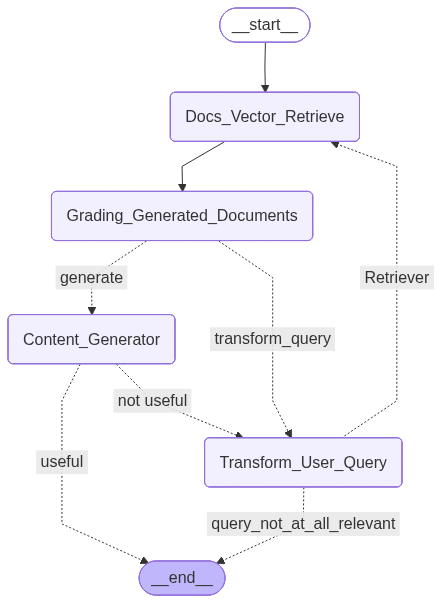

In [ ]:
from IPython.display import Image, display # type: ignore
display(Image(app.get_graph(xray=True).draw_mermaid_png()))

In [ ]:

inputs = {"question": "Explain how the different types of agent memory work?"}

In [ ]:
app.invoke(inputs)["generation"]

----RETRIEVE----
----CHECK DOCUMENTS RELEVANCE TO THE QUESTION----


BadRequestError: Error code: 400 - {'error': {'message': "Failed to call a function. Please adjust your prompt. See 'failed_generation' for more details.", 'type': 'invalid_request_error', 'code': 'tool_use_failed', 'failed_generation': "<function=GradeDocuments>binary_score='yes'}</function>"}}